In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
color = sns.color_palette()
import sklearn.metrics as metrics


import warnings
warnings.filterwarnings("ignore") #d

In [2]:
Default = pd.read_csv("Default.csv")
Default.head()

,Default,Students,Balance,Income
0,No,No,67894.34,1222098.12
1,Yes,No,56745.56,1021420.08
2,No,Yes,34567.45,622214.10
3,No,No,43689.56,786412.08
4,No,Yes,56324.56,1013842.08


In [3]:
Default.shape

(52, 4)

In [4]:
Default.describe()

,Balance,Income
count,52.000000,5.200000e+01
mean,63835.979038,1.149048e+06
std,59063.055541,1.063135e+06
min,6574.780000,1.183460e+05
25%,40880.972500,7.358575e+05
50%,56767.315000,1.021812e+06
75%,76245.752500,1.372424e+06
max,453467.760000,8.162420e+06


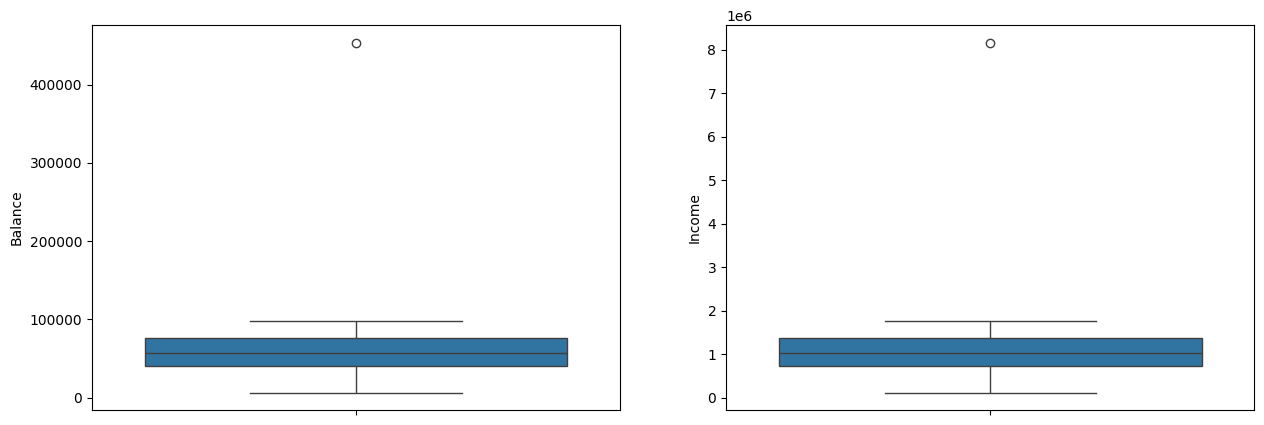

In [5]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(y = Default['Balance'])


plt.subplot(1,2,2)
sns.boxplot(y = Default['Income'])
plt.show()

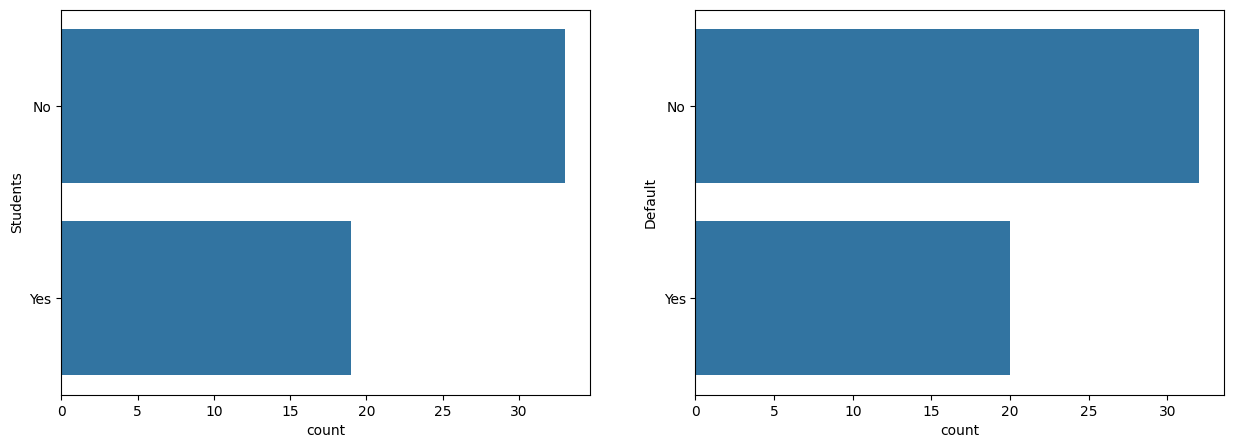

In [6]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.countplot(Default['Students'])

plt.subplot(1,2,2)
sns.countplot(Default['Default'])
plt.show()

In [7]:
Default["Students"].value_counts()

Students
No     33
Yes    19
Name: count, dtype: int64

In [8]:
Default["Default"].value_counts()

Default
No     32
Yes    20
Name: count, dtype: int64

In [9]:
Default["Students"].value_counts(normalize=True)

Students
No     0.634615
Yes    0.365385
Name: proportion, dtype: float64

In [10]:
Default["Default"].value_counts(normalize=True)

Default
No     0.615385
Yes    0.384615
Name: proportion, dtype: float64

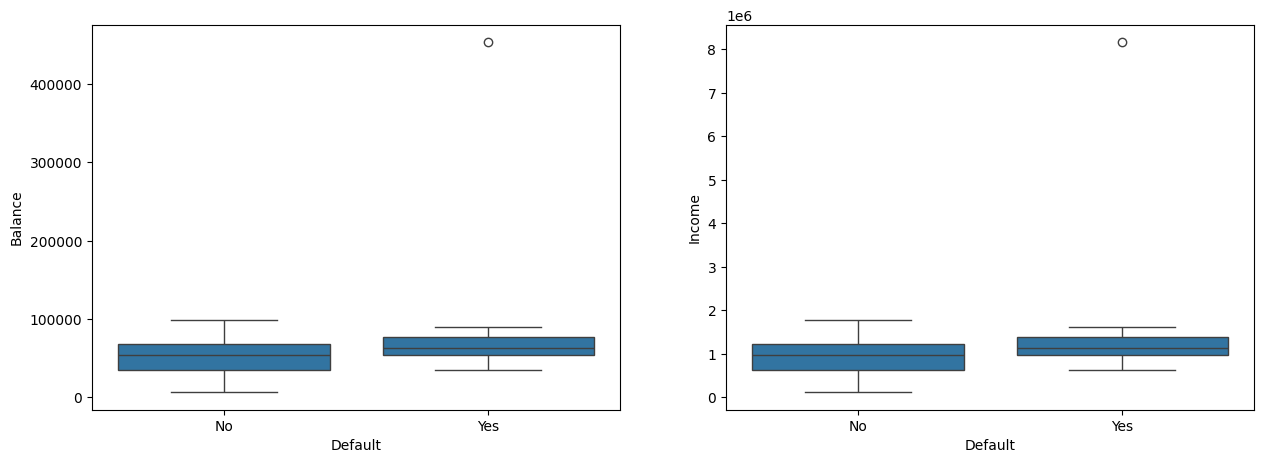

In [11]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(x='Default',y='Balance',data=Default)


plt.subplot(1,2,2)
sns.boxplot(x='Default',y='Income', data=Default)
plt.show()

#Default	Students	Balance	Income

In [12]:
pd.crosstab(Default['Students'],Default['Default'],normalize='index').round(2)

Default,No,Yes
Students,,
No,0.67,0.33
Yes,0.53,0.47


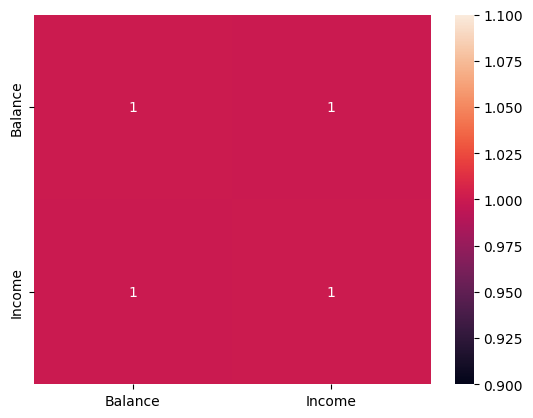

In [13]:
sns.heatmap(Default[['Balance','Income']].corr(),annot=True)
plt.show()

In [14]:
Default.isnull().sum()

Default     0
Students    0
Balance     0
Income      0
dtype: int64

In [15]:
Q1,Q3 = Default["Balance"].quantile([0.25,0.75])

In [16]:
IQR=Q3-Q1

In [17]:
LL=Q1 - 1.5*(IQR)

In [18]:
UL=Q3+1.5*(IQR)

In [19]:
UL

129292.92250000002

In [20]:
df = Default[Default["Balance"]>UL]

In [21]:
df

,Default,Students,Balance,Income
7,Yes,Yes,453467.76,8162419.68


In [22]:
df['Default'].count()

np.int64(1)

In [23]:
df['Default'].value_counts(normalize=True)

Default
Yes    1.0
Name: proportion, dtype: float64

In [24]:
df['Default'].value_counts()

Default
Yes    1
Name: count, dtype: int64

In [25]:
Default['Balance']=np.where(Default['Balance']>UL,UL,Default['Balance'])

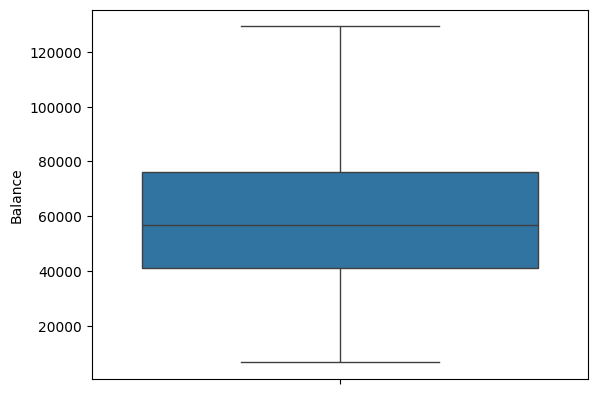

In [26]:
sns.boxplot(y=Default['Balance'])
plt.show()

In [27]:
Default=pd.get_dummies(Default,drop_first=True)

In [28]:
Default.head()

,Balance,Income,Default_Yes,Students_Yes
0,67894.34,1222098.12,False,False
1,56745.56,1021420.08,True,False
2,34567.45,622214.10,False,True
3,43689.56,786412.08,False,False
4,56324.56,1013842.08,False,True


In [29]:
Default.columns=['balance','income','default','student']

In [30]:
Default.head()

,balance,income,default,student
0,67894.34,1222098.12,False,False
1,56745.56,1021420.08,True,False
2,34567.45,622214.10,False,True
3,43689.56,786412.08,False,False
4,56324.56,1013842.08,False,True


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x=Default.drop('default',axis=1)
y=Default['default']

In [33]:
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=21,stratify=y)

In [34]:
print(x_train.shape)
print(x_test.shape)


(36, 3)
(16, 3)


In [35]:
print(y_train.value_counts(normalize=True).round(2))
print(' ')
print(y_test.value_counts(normalize=True).round(2))

default
False    0.61
True     0.39
Name: proportion, dtype: float64
 
default
False    0.62
True     0.38
Name: proportion, dtype: float64


In [36]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 33, sampling_strategy=0.75)
x_res,y_res = sm.fit_resample(x_train,y_train)

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
lr = LogisticRegression()

In [39]:
lr.fit(x_res,y_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = lr.predict(x_test)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

In [42]:
confusion_matrix(y_test,y_pred)

array([[8, 2],
       [4, 2]])

In [44]:
(2589+75)/(2589+75+311+25)

0.888

In [45]:
(3568+45)/(3568+45+213+12)

0.9413757165190203